In [1]:
import os
import pandas as pd
import numpy as np
import h5py
from sqlalchemy import create_engine
from scipy import stats
import plotly.express as px
import toml
import psrc_theme

%matplotlib inline
from IPython.display import display, HTML

# to show plotly figures in quarto HTML file
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"
pio.templates.default = "simple_white+psrc_color" # set plotly template

input_config = toml.load(os.path.join(os.getcwd(), '..\\..\\..\\..\\configuration', 'input_configuration.toml'))
valid_config = toml.load(os.path.join(os.getcwd(), '..\\..\\..\\..\\configuration', 'validation_configuration.toml'))
emme_config = toml.load(os.path.join(os.getcwd(), '..\\..\\..\\..\\configuration','emme_configuration.toml'))
network_config = toml.load(os.path.join(os.getcwd(), '..\\..\\..\\..\\configuration','network_configuration.toml'))

# create connection
conn = create_engine('sqlite:///../../../../inputs/db/'+input_config['db_name'])

# summary data location
csv_path = os.path.join(valid_config['model_dir'], 'outputs/validation')

# table format
pd.options.display.float_format = '{:0,.0f}'.format
format_percent = "{:,.1%}".format

## VMT

In [2]:
df = pd.read_csv(os.path.join(valid_config['model_dir'], r'outputs/network/county_network.csv'))
df.index = df.county_name
df.loc['Total',:] = df.sum().values
df = df[['VMT','VHT','delay']]
df

,VMT,VHT,delay
county_name,,,
King,"43,364,401",inf,"172,885"
Kitsap,"4,483,738","126,488","5,397"
Outside Region,"327,123","6,162",0
Pierce,"17,816,577","574,530","52,240"
Snohomish,"16,534,625","447,831","37,439"
Total,"82,526,465",inf,"267,962"


In [3]:
df = pd.read_csv(os.path.join(valid_config['model_dir'], r'outputs/network/county_network.csv'))

df_obs = pd.read_sql("SELECT * FROM observed_vmt WHERE year="+str(input_config['base_year']), con=conn)
df_obs.rename(columns={'vmt': 'observed'}, inplace=True)

df = df[['county_name','VMT']].merge(df_obs, left_on='county_name', right_on='county')
df.rename(columns={'VMT': 'model'}, inplace=True)
df.index = df['county']
df[['observed','model']] = df[['observed','model']].astype('float')

df.loc['Total',:] = df.sum().values

df['% diff'] = (df['model']-df['observed'])/df['observed']
df[['% diff']] = df[['% diff']].applymap(format_percent)
df[['model','observed','% diff']]

C:\Users\aditya.gore\AppData\Local\Temp\7\ipykernel_442396\2489709904.py:14: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,model,observed,% diff
county,,,
King,"43,364,401","43,820,112",-1.0%
Kitsap,"4,483,738","4,840,030",-7.4%
Pierce,"17,816,577","17,994,803",-1.0%
Snohomish,"16,534,625","15,825,794",4.5%
Total,"82,199,342","82,480,739",-0.3%


## Daily Traffic Counts

In [4]:
df = pd.read_csv(os.path.join(csv_path, 'daily_volume.csv'))
# df = df.groupby('@countid').agg({'modeled':'sum', 'observed':'first', '@facilitytype':'first'}).reset_index()
df[['modeled', 'observed']] = df[['modeled', 'observed']].astype('float')
_df = df.groupby('@facilitytype').sum()[['observed', 'modeled']]
_df.loc['Total', :] = _df.sum().values
_df['diff'] = _df['modeled'] - _df['observed']
_df['percent_diff'] = _df['diff'] / _df['observed']
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df

C:\Users\aditya.gore\AppData\Local\Temp\7\ipykernel_442396\1873497911.py:8: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,observed,modeled,diff,percent_diff
@facilitytype,,,,
Arterial,"18,066,275","15,855,213","-2,211,062",-12.2%
Collector,"2,535,809","1,880,521","-655,288",-25.8%
Freeway,"33,506,913","36,829,914","3,323,001",9.9%
HOV,"173,024","115,005","-58,019",-33.5%
Ramp,"1,855,280","1,684,328","-170,952",-9.2%
Total,"56,137,301","56,364,981","227,680",0.4%


In [5]:
#### Daily | By Facility Type - City of SeaTac

In [6]:
df1 = df[df['county'] == 'Pierce']

In [7]:
_df = df1.groupby('@facilitytype').sum()[['observed', 'modeled']]
_df.loc['Total', :] = _df.sum().values
_df['diff'] = _df['modeled'] - _df['observed']
_df['percent_diff'] = _df['diff'] / _df['observed']
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df

C:\Users\aditya.gore\AppData\Local\Temp\7\ipykernel_442396\608670790.py:5: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,observed,modeled,diff,percent_diff
@facilitytype,,,,
Arterial,"7,457,918","6,841,888","-616,030",-8.3%
Collector,"1,127,794","821,689","-306,105",-27.1%
Freeway,"6,697,295","10,966,442","4,269,147",63.7%
HOV,"71,598","8,745","-62,853",-87.8%
Ramp,"1,758,047","1,610,398","-147,649",-8.4%
Total,"17,112,652","20,249,162","3,136,510",18.3%


In [8]:
#### Daily | By Facility Type - Other Counties

In [9]:
df2 = df[df['county'] != 'Pierce']

In [10]:
_df = df2.groupby('@facilitytype').sum()[['observed', 'modeled']]
_df.loc['Total', :] = _df.sum().values
_df['diff'] = _df['modeled'] - _df['observed']
_df['percent_diff'] = _df['diff'] / _df['observed']
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df

C:\Users\aditya.gore\AppData\Local\Temp\7\ipykernel_442396\1534906848.py:5: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,observed,modeled,diff,percent_diff
@facilitytype,,,,
Arterial,"10,608,357","9,013,325","-1,595,032",-15.0%
Collector,"1,408,015","1,058,832","-349,183",-24.8%
Freeway,"26,809,618","25,863,472","-946,146",-3.5%
HOV,"101,426","106,260","4,834",4.8%
Ramp,"97,233","73,930","-23,303",-24.0%
Total,"39,024,649","36,115,819","-2,908,830",-7.5%


In [11]:
df = pd.read_csv(os.path.join(csv_path,'daily_volume_county_facility.csv'))
df[['modeled','observed']] = df[['modeled','observed']].astype('float')

_df = df.groupby('county').sum()[['observed','modeled']]
_df.loc['Total',:] = _df.sum().values
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df

C:\Users\aditya.gore\AppData\Local\Temp\7\ipykernel_442396\4255960492.py:8: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,observed,modeled,diff,percent_diff
county,,,,
King,"28,098,669","26,290,706","-1,807,963",-6.4%
Kitsap,"3,515,342","2,776,870","-738,472",-21.0%
Pierce,"17,112,652","20,249,162","3,136,510",18.3%
Snohomish,"7,410,638","7,048,243","-362,395",-4.9%
Total,"56,137,301","56,364,981","227,680",0.4%


In [12]:
df = pd.read_csv(os.path.join(csv_path,'daily_volume_by_flow.csv'))
df[['modeled','observed']] = df[['modeled','observed']].astype('float')
df['diff'] = df['modeled']-df['observed']
df['diff2'] = df['diff']**2
volume_bins = ['>=0 & <10,000', '>=10,000 & < 25,000', '>=25,000 & <50,000', '>=50,000 & <100,000', '>=100,000', 'Total']
df['volume_bins'] = df['volbin'].map(pd.Series(volume_bins, dtype='category')).cat.reorder_categories(volume_bins, ordered=True)
_df = df.groupby('volume_bins', sort=True).agg({'modeled':'sum', 'observed':'sum', 'nlinks':'count', 'diff2':'sum'}).reset_index().set_index('volume_bins')
_df.loc['Total',:] = _df.sum().values
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df['rmse'] = ((_df['diff2']/(_df['nlinks']-1))**0.5)/(_df['observed']/_df['nlinks'])
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df[['rmse']] = _df[['rmse']].applymap(format_percent)
_df.drop(columns='diff2').rename(columns={'nlinks':'ncounts'})[['observed', 'modeled', 'ncounts', 'diff', 'percent_diff', 'rmse']]


C:\Users\aditya.gore\AppData\Local\Temp\7\ipykernel_442396\3353764135.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\aditya.gore\AppData\Local\Temp\7\ipykernel_442396\3353764135.py:12: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.

C:\Users\aditya.gore\AppData\Local\Temp\7\ipykernel_442396\3353764135.py:13: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,observed,modeled,ncounts,diff,percent_diff,rmse
volume_bins,,,,,,
">=0 & <10,000","8,131,306","5,426,155",1462,"-2,705,151",-33.3%,74.5%
">=10,000 & < 25,000","10,046,023","8,936,743",555,"-1,109,280",-11.0%,47.7%
">=25,000 & <50,000","10,980,451","10,814,154",296,"-166,297",-1.5%,36.8%
">=50,000 & <100,000","17,603,417","19,051,218",253,"1,447,801",8.2%,31.0%
">=100,000","9,376,104","12,136,711",90,"2,760,607",29.4%,55.1%
Total,"56,137,301","56,364,981",2656,"227,680",0.4%,67.0%


In [13]:
_df = df[df['county'] == 'Pierce'].groupby('volume_bins', sort=True, observed=False).agg({'modeled':'sum', 'observed':'sum', 'nlinks':'count', 'diff2':'sum'}).reset_index().set_index('volume_bins')
_df.loc['Total',:] = _df.sum().values
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df['rmse'] = ((_df['diff2']/(_df['nlinks']-1))**0.5)/(_df['observed']/_df['nlinks'])
_df[['percent_diff']] = _df[['percent_diff']].map(format_percent)
_df[['rmse']] = _df[['rmse']].map(format_percent)
_df.drop(columns='diff2').rename(columns={'nlinks':'ncounts'})[['observed', 'modeled', 'ncounts', 'diff', 'percent_diff', 'rmse']]

,observed,modeled,ncounts,diff,percent_diff,rmse
volume_bins,,,,,,
">=0 & <10,000","4,594,357","3,273,843",984,"-1,320,514",-28.7%,72.1%
">=10,000 & < 25,000","3,355,472","3,246,309",206,"-109,163",-3.3%,34.4%
">=25,000 & <50,000","2,647,061","3,095,088",85,"448,027",16.9%,56.9%
">=50,000 & <100,000","3,093,317","4,986,779",65,"1,893,462",61.2%,76.1%
">=100,000","3,231,940","5,626,624",39,"2,394,684",74.1%,90.8%
Total,"16,922,147","20,228,643",1379,"3,306,496",19.5%,128.6%


## Daily Traffic Scatterplot

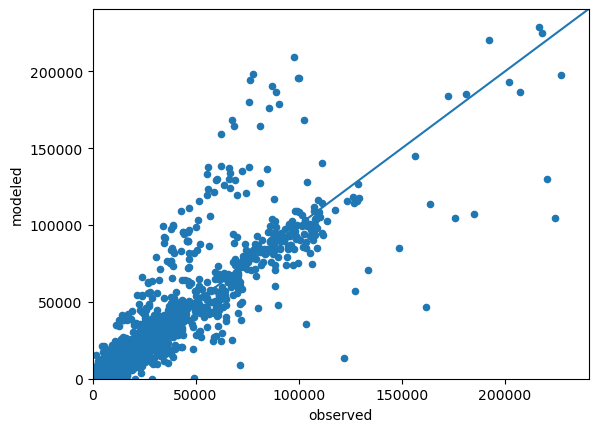

In [14]:
df = pd.read_csv(os.path.join(csv_path,'daily_volume.csv'))
ax = df.plot(kind='scatter', x='observed', y='modeled')
lim = df[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)

In [15]:
slope, intercept, r_value, p_value, std_err = stats.linregress(df['observed'],df['modeled'])
print('r^2: ' + str(r_value))

r^2: 0.8932985882892384


King r^2: 0.9415183315347979
Kitsap r^2: 0.900316609111409
Pierce r^2: 0.8573653312335137
Snohomish r^2: 0.9421740351421183


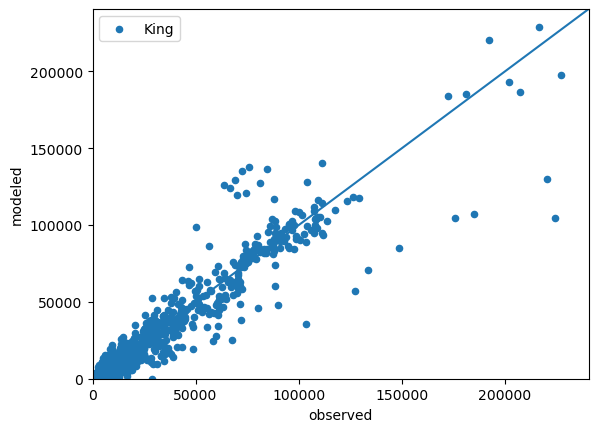

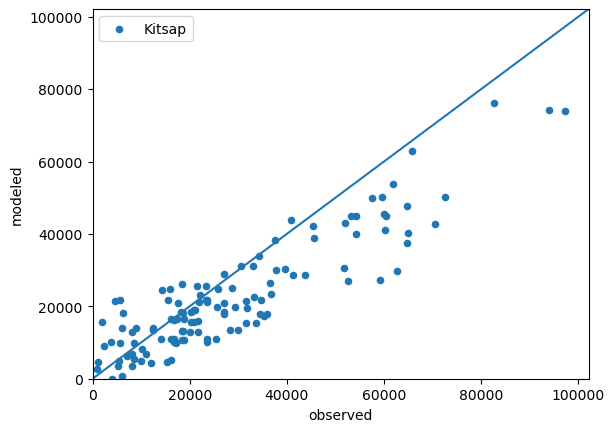

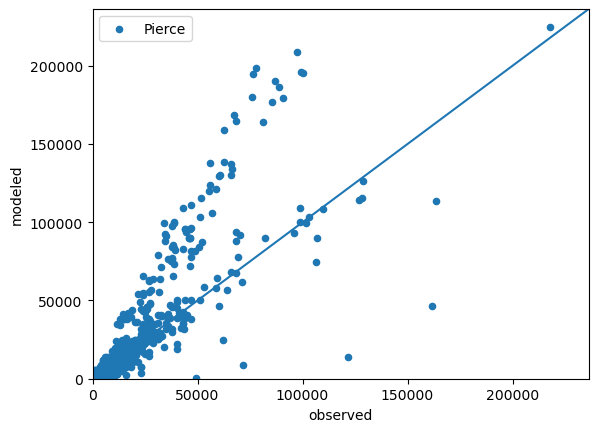

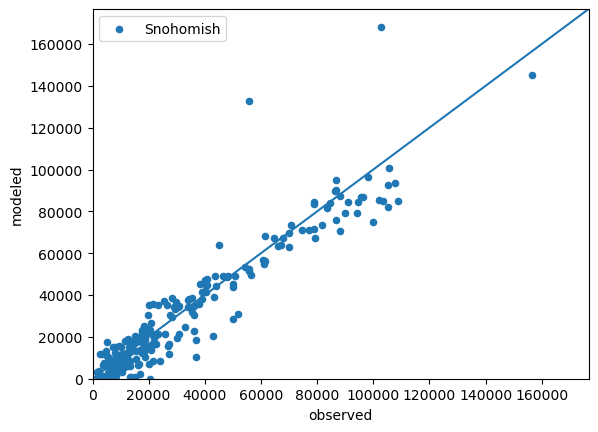

In [16]:
for county in np.unique(df['county']):
    _df = df[df['county'] == county]
    ax = _df.plot(kind='scatter', x='observed', y='modeled', label=county)
    lim = _df[['observed','modeled']].max().max()*1.05
    ax.set_ylim(0,lim)
    ax.set_xlim(0,lim)
    slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed'],_df['modeled'])
    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x)
    print(str(county) + ' r^2: ' + str(r_value))

r^2 Freeway: 0.722847219181364
r^2 Arterial: 0.8575832245552166


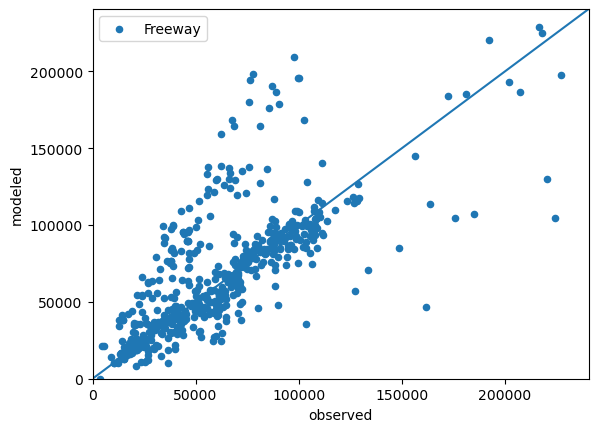

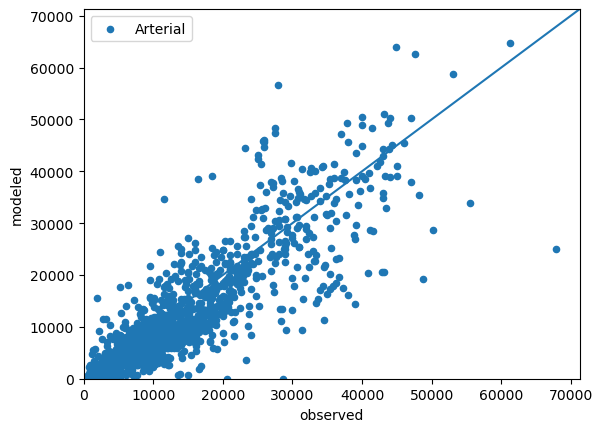

In [17]:
for factype in ['Freeway','Arterial']:
# for factype in ['Freeway']:
    _df = df[df['@facilitytype'] == factype]
    ax = _df.plot(kind='scatter', x='observed', y='modeled', label=factype)
    lim = _df[['observed','modeled']].max().max()*1.05
    ax.set_ylim(0,lim)
    ax.set_xlim(0,lim)
    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x)
    slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed'],_df['modeled'])
    print('r^2 ' + str(factype) + ': ' + str(r_value))

r^2 Freeway: 0.5762051298157119
r^2 Arterial: 0.9038295872098546


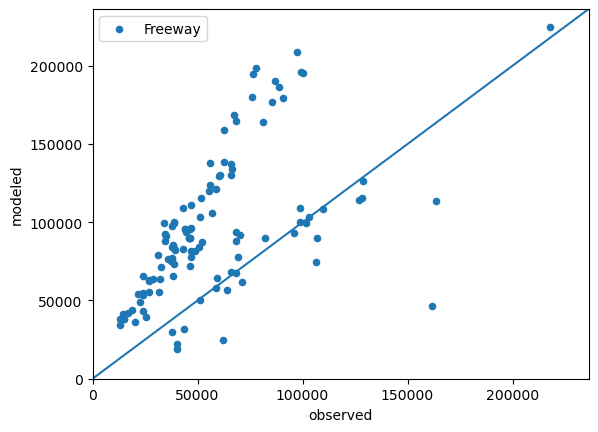

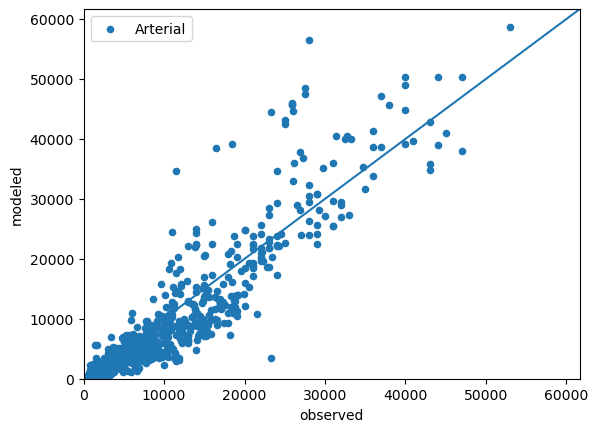

In [18]:
df1 = df[df['county'] == 'Pierce']
for factype in ['Freeway','Arterial']:
    _df = df1[df1['@facilitytype'] == factype]
    ax = _df.plot(kind='scatter', x='observed', y='modeled', label=factype)
    lim = _df[['observed','modeled']].max().max()*1.05
    ax.set_ylim(0,lim)
    ax.set_xlim(0,lim)
    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x)
    slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed'],_df['modeled'])
    print('r^2 ' + str(factype) + ': ' + str(r_value))

r^2 Freeway: 0.8750119699485546
r^2 Arterial: 0.8150608299093812


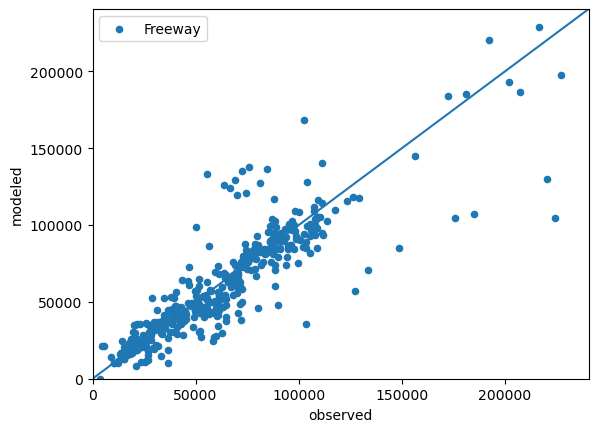

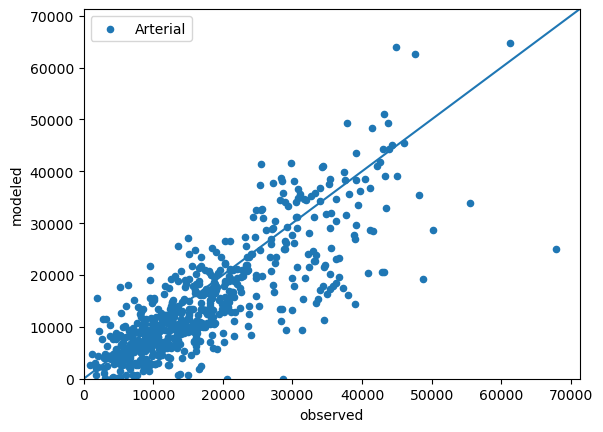

In [19]:
df2 = df[(df['county'] != 'Pierce') & (~df.county.isna())]
if df2.shape[0] > 0:
    for factype in ['Freeway','Arterial']:
        _df = df2[df2['@facilitytype'] == factype]
        ax = _df.plot(kind='scatter', x='observed', y='modeled', label=factype)
        lim = _df[['observed','modeled']].max().max()*1.05
        ax.set_ylim(0,lim)
        ax.set_xlim(0,lim)
        x = np.linspace(*ax.get_xlim())
        ax.plot(x, x)
        slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed'],_df['modeled'])
        print('r^2 ' + str(factype) + ': ' + str(r_value))

In [20]:
## hourly volumnes

r^2: 0.7997112293373146


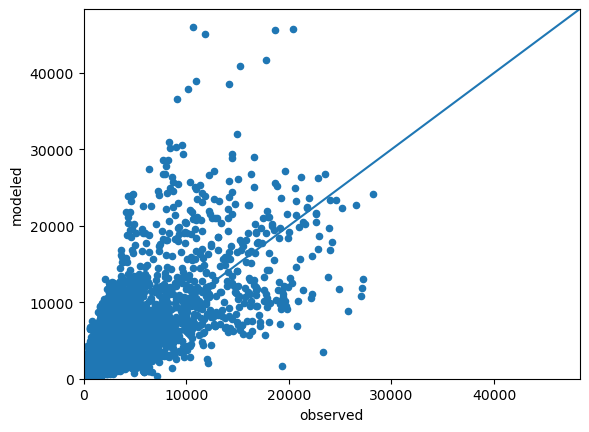

In [21]:
df = pd.read_csv(os.path.join(csv_path,'hourly_volume.csv'))
ax = df.plot(kind='scatter', x='observed', y='modeled')
lim = df[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df['observed'],df['modeled'])
print('r^2: ' + str(r_value))

In [22]:
## hourly volumnes - Pierce County

r^2: 0.791771890569101


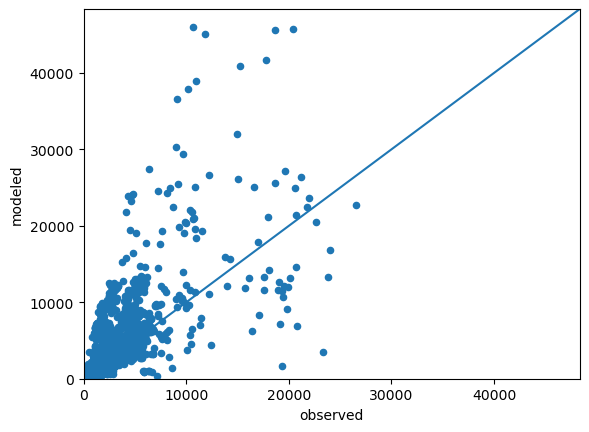

In [23]:
df1 = df[df['county'] == 'Pierce']
ax = df1.plot(kind='scatter', x='observed', y='modeled')
lim = df1[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df1['observed'],df1['modeled'])
print('r^2: ' + str(r_value))

In [24]:
## hourly volumnes - Other

r^2: 0.6645380289944325

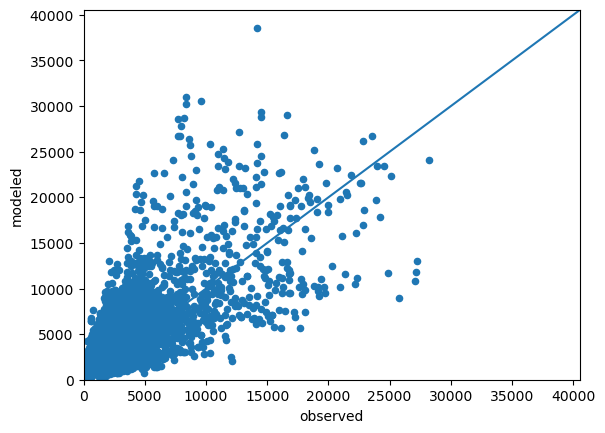

In [25]:
df2 = df[df['county'] != 'Pierce']
ax = df2.plot(kind='scatter', x='observed', y='modeled')
lim = df2[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df2['observed'],df2['modeled'])
print('r^2: ' + str(r_value))

## Screenlines

In [26]:
df = pd.read_csv(os.path.join(csv_path,'screenlines.csv'))
df = df.groupby(['name', 'county'], as_index=False).agg({'observed':'first', 'modeled':'sum'})
df['diff'] = df['modeled']-df['observed']
df = pd.concat([df,df.sum(numeric_only=True).to_frame().T], ignore_index=True, axis=0)
df.at[df.index[-1], 'name'] = 'TOTAL'
#df.at['C', 'name'] = 10
df['percent_diff'] = df['diff']/df['observed']
df[['percent_diff']] = df[['percent_diff']].applymap(format_percent)
df.sort_values(['county','observed'], ascending=[True, False])

C:\Users\aditya.gore\AppData\Local\Temp\7\ipykernel_442396\331908952.py:8: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,name,county,observed,modeled,diff,percent_diff
1,AUBURN - SOUTH KING,King,"592,476","501,602","-90,874",-15.3%
12,KENT,King,"559,335","476,130","-83,205",-14.9%
29,SHIP CANAL,King,"481,563","511,910","30,347",6.3%
28,SEATTLE - SOUTH OF CBD,King,"473,322","476,211","2,889",0.6%
16,MILL CREEK,King,"391,447","320,727","-70,720",-18.1%
30,SOUTH BELLEVUE,King,"389,700","333,976","-55,724",-14.3%
13,KIRKLAND-REDMOND,King,"380,783","393,468","12,685",3.3%
27,SEATTLE - NORTH,King,"356,051","337,419","-18,632",-5.2%
2,BOTHELL,King,"291,573","208,057","-83,516",-28.6%
14,LYNNWOOD-BOTHELL,King,"260,099","279,862","19,763",7.6%


r^2 : 0.9751150308317027


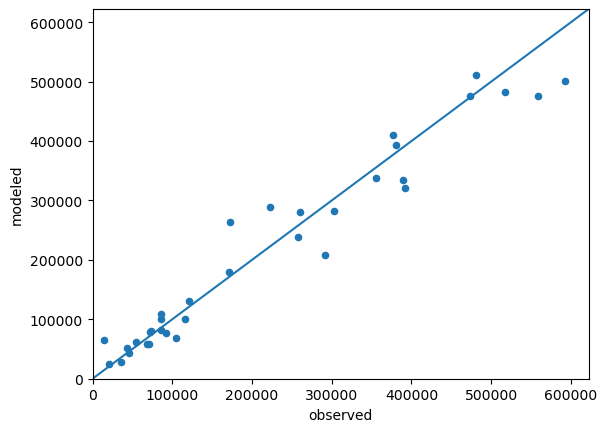

In [27]:
df = df.head(-1)
ax = df.plot(kind='scatter', x='observed', y='modeled')
lim = df[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df['observed'],df['modeled'])
print('r^2 : ' + str(r_value))

### Screenlines - Pierce County

In [28]:
df = pd.read_csv(os.path.join(csv_path,'screenlines.csv'))
# df = df[~df.name.isin(['KENT','SEATAC'])]
df1 = df[(df['county'] == 'Pierce') ]
df1 = df1.groupby(['name', 'county'], as_index=False).agg({'observed':'first', 'modeled':'sum'})
df1['diff'] = df1['modeled'] - df1['observed']
df1 = pd.concat([df1,pd.DataFrame([df1.sum(numeric_only=True)], index=['Total'])], axis=0, ignore_index=False)
# df1.at[df1.index[-1], 'name'] = 'TOTAL'
#df1.at['C', 'name'] = 10
df1['percent_diff'] = df1['diff']/df1['observed']
df1['percent_diff'] = df1['percent_diff'].apply(format_percent)
df1.sort_values(['county','observed'], ascending=[True, False])

,name,county,observed,modeled,diff,percent_diff
9,NS-02,Pierce,"517,266","483,015","-34,251",-6.6%
4,EW-05,Pierce,"376,912","410,884","33,972",9.0%
3,EW-04,Pierce,"302,884","281,953","-20,931",-6.9%
5,EW-06,Pierce,"172,178","263,496","91,318",53.0%
2,EW-03,Pierce,"170,814","178,861","8,047",4.7%
7,EW-08,Pierce,"120,500","130,149","9,649",8.0%
10,NS-03,Pierce,"91,908","77,574","-14,334",-15.6%
1,EW-02,Pierce,"86,000","109,204","23,204",27.0%
12,NS-05,Pierce,"85,764","100,460","14,696",17.1%
0,EW-01,Pierce,"72,780","80,406","7,626",10.5%


r^2 : 0.9790090762175027


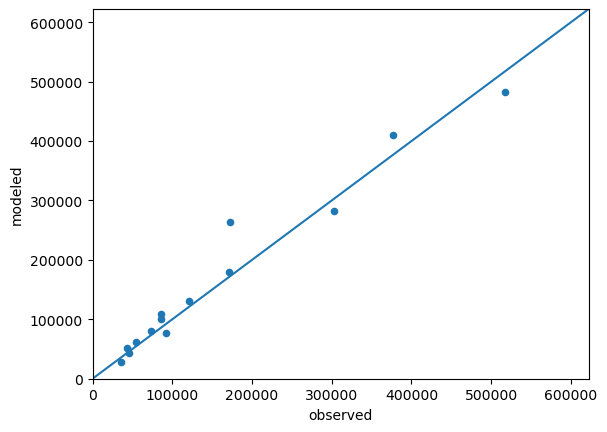

In [29]:
import warnings
warnings.filterwarnings('ignore')
df1 = df1.head(-1)
ax = df1.plot(kind='scatter', x='observed', y='modeled')
lim = df[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df1['observed'],df1['modeled'])
print('r^2 : ' + str(r_value))

### Screenlines - Other

In [30]:
df2 = df[(df['county'] != 'Pierce') ].groupby(['name','county'],as_index=False).agg({'observed':'first','modeled':'sum'})
df2['diff'] = df2['modeled']-df2['observed']
df2 = pd.concat([df2,pd.DataFrame([df2.sum(numeric_only=True)], index=['Total'])], axis=0, ignore_index=False)
#df2.at['C', 'name'] = 10
df2['percent_diff'] = df2['diff']/df2['observed']
df2['percent_diff'] = df2['percent_diff'].apply(format_percent)
df2

,name,county,observed,modeled,diff,percent_diff
0,AGATE PASS BRIDGE,Kitsap,"21,000","25,529","4,529",21.6%
1,AUBURN - SOUTH KING,King,"592,476","501,602","-90,874",-15.3%
2,BOTHELL,King,"291,573","208,057","-83,516",-28.6%
3,CROSS SOUND,Kitsap,"14,302","65,710","51,408",359.4%
4,KENT,King,"559,335","476,130","-83,205",-14.9%
5,KIRKLAND-REDMOND,King,"380,783","393,468","12,685",3.3%
6,LYNNWOOD-BOTHELL,King,"260,099","279,862","19,763",7.6%
7,MAPLE VALLEY,King,"70,813","57,787","-13,026",-18.4%
8,MILL CREEK,King,"391,447","320,727","-70,720",-18.1%
9,NORTH KITSAP,Kitsap,"104,890","68,686","-36,204",-34.5%


r^2 : 0.9733242071379706

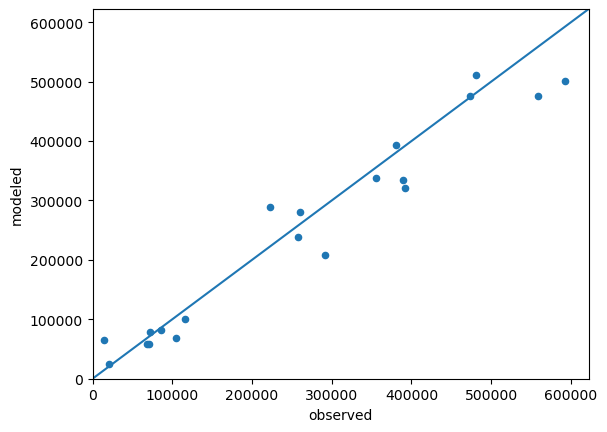

In [31]:
df2 = df2.head(-1)
if df2.shape[0] > 0:
    ax = df2.plot(kind='scatter', x='observed', y='modeled')
    lim = df[['observed','modeled']].max().max()*1.05
    ax.set_ylim(0,lim)
    ax.set_xlim(0,lim)
    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x)
    slope, intercept, r_value, p_value, std_err = stats.linregress(df2['observed'],df2['modeled'])
    print('r^2 : ' + str(r_value))

# External Stations

In [32]:
df = pd.read_csv(os.path.join(csv_path,'external_volumes.csv'), index_col='location')
df = df.drop('diff', axis=1)
df['diff'] = df['modeled']-df['observed']
df = df.fillna(0)
df.loc['Total',['observed','modeled','diff']] = df[['observed','modeled','diff']].sum()
df['percent_diff'] = df['diff']/df['observed']
df[['percent_diff']] = df[['percent_diff']].applymap(format_percent)
df.replace('nan', '', regex=True)

,external_station,county,observed,modeled,diff,percent_diff
location,,,,,,
I-5 to Olympia,"3,733",Pierce,"129,250","130,149",899,0.7%
I-5 to Mount Vernon,"3,744",Snohomish,"65,880","63,561","-2,319",-3.5%
I-90 @ Snoqualmie Pass,"3,739",King,"30,500","32,892","2,392",7.8%
SR-507 to Yelm,"3,734",Pierce,"22,700","22,652",-48,-0.2%
SR-532 to Camano Island,"3,746",Snohomish,"21,250","20,713",-537,-2.5%
SR-3 to Belfair,"3,749",Kitsap,"20,329","18,459","-1,870",-9.2%
Hood Canal Bridge,"3,748",Kitsap,"18,200","18,343",143,0.8%
Mukilteo-Clinton Ferry,"3,747",Snohomish,"9,800","5,957","-3,843",-39.2%
SR-530 N/O Stanwood,"3,745",Snohomish,"9,100","9,140",40,0.4%


r^2 : 0.9990797230716473


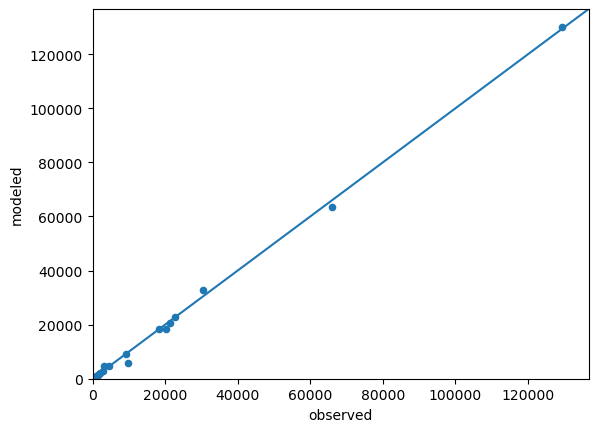

In [33]:
df = df.head(-1)
ax = df.plot(kind='scatter', x='observed', y='modeled')
lim = df[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df['observed'],df['modeled'])
print('r^2 : ' + str(r_value))

In [34]:
## External trips/VMT
df_23 = h5py.File(r'..\..\..\..\inputs\model\daysim\roster\7to8.h5')
df_23_skims_sov = df_23['Skims']['sov_inc2d'][:]/100
df_23_skims_hov2 = df_23['Skims']['hov2_inc2d'][:]/100
df_23_skims_hov3 = df_23['Skims']['hov3_inc2d'][:]/100

df_results_new = pd.DataFrame()

tod_list = ['5to6', '6to7', '7to8', '8to9', '9to10', '10to14', '14to15', '15to16', '16to17', '17to18', '18to20', '20to5']
for tod in tod_list:
#     print(tod)
    df_temp = pd.DataFrame()
    for mode in ['sov','hov2','hov3']:
#         print(mode)
        od_new = h5py.File(r'..\..\..\..\outputs\supplemental\external_work_'+tod+'.h5', 'r')[mode][:]
        df_temp.loc[tod,mode+'_vmt'] = (df_23_skims_sov*od_new).sum()
        df_temp.loc[tod,mode+'_trips'] = od_new.sum()
        df_temp.loc[tod,mode+'_avg_dist'] = df_temp.loc[tod,mode+'_vmt']/df_temp.loc[tod,mode+'_trips']
    df_results_new = pd.concat([df_results_new, df_temp ])

In [35]:
df_vmt = pd.DataFrame(df_results_new[['sov_vmt','hov2_vmt','hov3_vmt']].sum(),
            columns=['VMT'])
df_vmt.index = [i.split('_')[0].upper() for i in df_vmt.index]

df_trips = pd.DataFrame(df_results_new[['sov_trips','hov2_trips','hov3_trips']].sum(),
            columns=['Trips'])
df_trips.index = [i.split('_')[0].upper() for i in df_trips.index]

df = df_vmt.merge(df_trips, left_index=True, right_index=True)

df.loc['Total',:] = df.sum(axis=0)
df['Avg Distance'] = df['VMT']/df['Trips']
df

,VMT,Trips,Avg Distance
SOV,"7,486,135","237,921",31
HOV2,"568,942","17,584",32
HOV3,"209,572","6,184",34
Total,"8,264,649","261,689",32


# Trucks

In [36]:
daily_counts = pd.read_sql("SELECT * FROM daily_counts WHERE year="+str(input_config['base_year']), con=conn)

daily_counts['htrk_vehicles'] = daily_counts['htrk_vehicles'].astype('float').fillna(-1)

facility_type_lookup = {
    1: "Freeway",  # Interstate
    2: "Freeway",  # Ohter Freeway
    3: "Freeway",  # Expressway
    4: "Ramp",
    5: "Arterial",  # Principal arterial
    6: "Arterial",  # Minor Arterial
    7: "Collector",  # Major Collector
    8: "Collector",  # Minor Collector
    9: "Collector",  # Local
    10: "Busway",
    11: "Non-Motor",
    12: "Light Rail",
    13: "Commuter Rail",
    15: "Ferry",
    16: "Passenger Only Ferry",
    17: "Connector",  # centroid connector
    18: "Connector",  # facility connector
    19: "HOV",  # HOV Only Freeway
    20: "HOV",  # HOV Flag
}

In [37]:
# FIXME: move to validation.py
df_network = pd.read_csv(r"..\..\..\..\outputs\network\network_results.csv")
model_vol_df = df_network.copy()
model_vol_df["@facilitytype"] = model_vol_df["@facilitytype"].map(
    facility_type_lookup
)

# Get daily and model volumes
df_daily = (
    model_vol_df.groupby(["@countid"])
    .agg({"@tveh": "sum", "@facilitytype": "first", '@mveh': 'sum', '@hveh': 'sum'})
    .reset_index()
)

# Merge observed with model
df_daily = df_daily.merge(daily_counts, left_on="@countid", right_on="flag")

In [38]:
county_lookup = {
    33: 'King',
    35: 'Kitsap',
    53: 'Pierce',
    61: 'Snohomish'
}

df_daily['County'] = df_daily['countyid'].map(county_lookup)

In [39]:
df_daily_med = df_daily.copy()
df_daily_med.rename(columns={'@mveh': 'Model', 'mtrk_vehicles': 'Observed'}, inplace=True)
df_daily_med = df_daily_med[~df_daily_med['Observed'].isnull()]
for col in ['Model','Observed']:
    df_daily_med[col] = df_daily_med[col].astype('int')
df_daily_med = df_daily_med[df_daily_med['Observed'] > 0]

df_daily_heavy = df_daily.copy()
df_daily_heavy.rename(columns={'@hveh': 'Model', 'htrk_vehicles': 'Observed'}, inplace=True)
df_daily_heavy = df_daily_heavy[~df_daily_heavy['Observed'].isnull()]
for col in ['Model','Observed']:
    df_daily_heavy[col] = df_daily_heavy[col].astype('int')
df_daily_heavy = df_daily_heavy[df_daily_heavy['Observed'] > 0]

In [40]:
def create_truck_chart(df_daily, truck_type, county=None):

    if county:
        df_daily = df_daily[df_daily['County'] == county]
        title = truck_type + ' Trucks: '+county
    else:
        title = truck_type + ' Trucks: Region'

    slope, intercept, r_value, p_value, std_err = stats.linregress(df_daily['Observed'], df_daily['Model'])

    fig = px.scatter(df_daily, y='Model', x='Observed', title=title, hover_data=['location','County'])
    fig.update_layout(height=600, width=800, margin=dict(l=100, r=100, t=100, b=100))

    # Get max value, either observed or modeled
    max_val = df_daily[['Observed','Model']].max().max()

    # Add 45-degree line
    fig.add_shape(
        type="line",
        x0=0, y0=0,
        x1=max_val, y1=max_val,
        line=dict(color="Red", width=2, dash="dash")
    )

    # Add best fit line
    x_fit = np.linspace(0, max(df_daily['Observed']), 100)
    y_fit = slope * x_fit + intercept
    fig.add_trace(px.line(x=x_fit, y=y_fit, labels={'x':'Observed', 'y':'Model'}).data[0])
    fig.update_traces(line=dict(color="Grey", width=2))

    # Add label for 45-degree line

    fig.add_annotation(
        x=max_val*1.05,
        y=max_val*1.05,
        text='y = x',
        showarrow=False,
        font=dict(size=12, color="pink"),
        align="right"
    )

    # Add R-squared value as annotation
    fig.add_annotation(
        x=max(x_fit)*1.05,
        y=max(y_fit)*1.05,
        text=f'r^2 = {r_value**2:.2f}',
        showarrow=False,
        font=dict(size=12, color="black"),
        align="right"
    )

    return fig


### Heavy Truck Counts

In [41]:
_df = df_daily_heavy.groupby('@facilitytype').sum()[['Observed','Model']].rename(columns={'Model':'modeled','Observed':'observed'})
_df.loc['Total',:] = _df.sum().values
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df['percent_diff'] = _df['percent_diff'].apply(format_percent)
_df.reindex(['Freeway', 'Arterial', 'Collector', 'Ramp', 'Total'])

,observed,modeled,diff,percent_diff
@facilitytype,,,,
Freeway,"142,993","208,965","65,972",46.1%
Arterial,"14,266","17,633","3,367",23.6%
Collector,100,1,-99,-99.0%
Ramp,"8,869","2,151","-6,718",-75.7%
Total,"166,228","228,750","62,522",37.6%


In [42]:
fig = create_truck_chart(df_daily_heavy, 'Heavy')
fig.show()

In [43]:
fig = create_truck_chart(df_daily_heavy, 'Heavy', 'King')
fig.show()

In [44]:
fig = create_truck_chart(df_daily_heavy, 'Heavy', 'Kitsap')
fig.show()

In [45]:
fig = create_truck_chart(df_daily_heavy, 'Heavy', 'Pierce')
fig.show()

In [46]:
fig = create_truck_chart(df_daily_heavy, 'Heavy', 'Snohomish')
fig.show()

### Medium Truck Counts

In [47]:
_df = df_daily_med.groupby('@facilitytype').sum()[['Observed','Model']].rename(columns={'Model':'modeled','Observed':'observed'})
_df.loc['Total',:] = _df.sum().values
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df['percent_diff'] = _df['percent_diff'].apply(format_percent)
_df.reindex(['Freeway', 'Arterial', 'Collector', 'Ramp', 'Total'])

,observed,modeled,diff,percent_diff
@facilitytype,,,,
Freeway,"138,284","202,345","64,061",46.3%
Arterial,"42,346","47,135","4,789",11.3%
Collector,434,35,-399,-91.9%
Ramp,"9,301","3,366","-5,935",-63.8%
Total,"190,365","252,881","62,516",32.8%


In [48]:
fig = create_truck_chart(df_daily_med, 'Medium')
fig.show()

In [49]:
fig = create_truck_chart(df_daily_med, 'Medium', 'King')
fig.show()

In [50]:
fig = create_truck_chart(df_daily_med, 'Medium', 'Kitsap')
fig.show()

In [51]:
fig = create_truck_chart(df_daily_med, 'Medium', 'Pierce')
fig.show()

In [52]:
fig = create_truck_chart(df_daily_med, 'Medium', 'Snohomish')
fig.show()

### Total Truck Counts

In [53]:
df_daily_total = df_daily.copy()
df_daily_total['Model'] = df_daily_total['@mveh'] + df_daily_total['@hveh']
df_daily_total['Observed'] = df_daily_total['mtrk_vehicles'] + df_daily_total['htrk_vehicles']
df_daily_total = df_daily_total[~df_daily_total['Observed'].isnull()]
for col in ['Model','Observed']:
    df_daily_total[col] = df_daily_total[col].astype('int')
df_daily_total = df_daily_total[df_daily_total['Observed'] > 0]
_df = df_daily_total.groupby('@facilitytype').sum()[['Observed','Model']].rename(columns={'Model':'modeled','Observed':'observed'})
_df.loc['Total',:] = _df.sum().values
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df['percent_diff'] = _df['percent_diff'].apply(format_percent)
_df.reindex(['Freeway', 'Arterial', 'Collector', 'Ramp', 'Total'])


,observed,modeled,diff,percent_diff
@facilitytype,,,,
Freeway,"281,277","411,352","130,075",46.2%
Arterial,"56,612","64,797","8,185",14.5%
Collector,534,36,-498,-93.3%
Ramp,"18,170","5,518","-12,652",-69.6%
Total,"356,593","481,703","125,110",35.1%


r^2: 0.7136902854381548


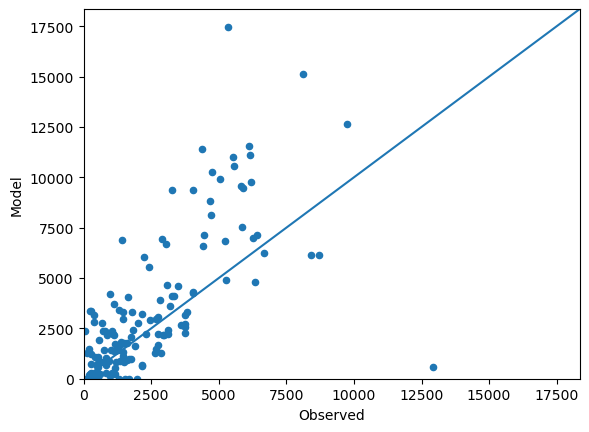

In [54]:
ax = df_daily_total.plot(kind='scatter', x='Observed', y='Model')
lim = df_daily_total[['Observed','Model']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df_daily_total['Observed'],df_daily_total['Model'])
print('r^2: ' + str(r_value))